# Week 14 - Bivariate Analysis 2, Statistics - Week 2

# 1. Lesson: no lesson this week.

# 2. Weekly graph question

What is your opinion of the graph below?  What are its positive or negative qualities?  How would you fix it?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
size = 5
interval = 30
start = datetime.datetime(2024, 1, 1)
  
lst = [start + datetime.timedelta(days=num_days) * interval for num_days in range(size)]

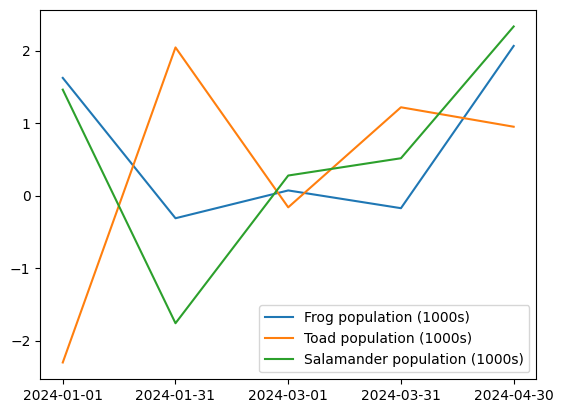

In [3]:
np.random.seed(1)
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Frog population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Toad population (1000s)")
plt.plot(lst, np.random.normal(size = size) + 0.3 * np.arange(size), label = "Salamander population (1000s)")
plt.xticks(lst)
plt.legend()

The graph shows trends for frog, toad, and salamander populations over time. While it communicates multiple time series, it has several strengths and weaknesses.

One positive aspect is that it includes a legend, which helps identify each line. The use of a time-based x-axis is also appropriate for showing trends over time.

However, there are several issues. The x-axis labels are crowded and difficult to read because all dates are shown and not formatted clearly. The lines are not visually distinct enough, which makes it harder to compare the populations. Additionally, the title is missing, so the viewer does not immediately understand the purpose of the graph. The units (in thousands) are only shown in the legend, which could be clearer if included in the axis label.

To improve the graph, I would:

Add a clear and descriptive title
Format the x-axis dates to be more readable (e.g., rotate or reduce labels)
Use different line styles or colors to distinguish the populations more clearly
Add axis labels for clarity
Reduce clutter by spacing out the x-axis ticks

These improvements would make the graph easier to read and better communicate the data and the following code is the improved version

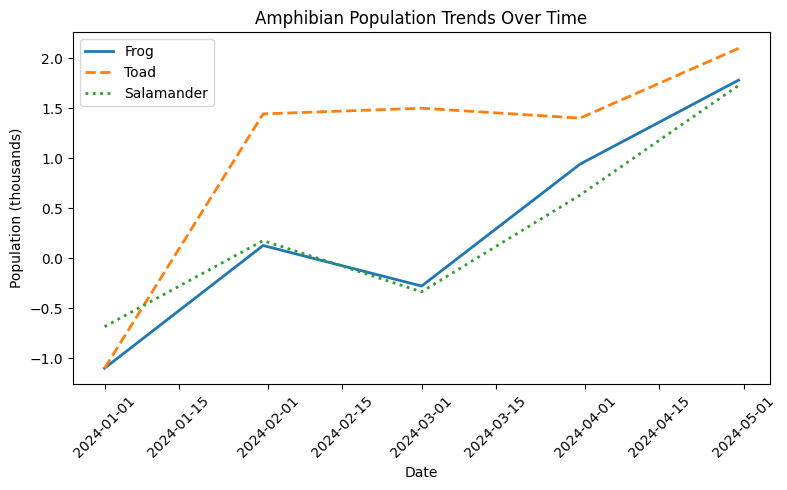

In [4]:
plt.figure(figsize=(8,5))

plt.plot(lst, np.random.normal(size=size) + 0.3 * np.arange(size),
         label="Frog", linewidth=2)

plt.plot(lst, np.random.normal(size=size) + 0.3 * np.arange(size),
         label="Toad", linewidth=2, linestyle="--")

plt.plot(lst, np.random.normal(size=size) + 0.3 * np.arange(size),
         label="Salamander", linewidth=2, linestyle=":")

plt.title("Amphibian Population Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Population (thousands)")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Run t-tests and Mann Whitney U tests to compare different sets of numbers.
  * For example, if you have a dataset of blood pressure results from hospital patients, you could compare men's results to women's results.
* Run ANOVA tests to compare more than two sets of numbers.
  * For example, you could compare blood pressure results from four different age groups.
* Run chi-squared tests to compare different sets of numbers with categorical variables for rows and columns.
  * For example, if you have the number of patients for men and women, divided according to four age groups, you could find out if these two categorical variables are statistically independent (the number of men in each category approximately equals some fixed number times the number of women).

In [11]:
import pandas as pd

# Load your dataset
df = pd.read_csv("marketing_and_product_performance.csv")

# Fix separator issue if needed
if df.shape[1] == 1:
    df = pd.read_csv("bank.csv", sep=";")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

df.head()

,campaign_id,product_id,budget,clicks,conversions,revenue_generated,roi,customer_id,subscription_tier,subscription_length,flash_sale_id,discount_level,units_sold,bundle_id,bundle_price,customer_satisfaction_post_refund,common_keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [13]:
# Create binary group: high vs low conversions
df["conversion_group"] = (df["conversions"] > df["conversions"].median())

df["conversion_group"].value_counts()

conversion_group
False    5001
True     4999
Name: count, dtype: int64

In [14]:
from scipy import stats

high_group = df[df["conversion_group"] == True]["revenue_generated"]
low_group = df[df["conversion_group"] == False]["revenue_generated"]

# T-test
t_stat, t_p = stats.ttest_ind(high_group, low_group)

# Mann-Whitney
u_stat, u_p = stats.mannwhitneyu(high_group, low_group)

print("T-test p-value:", t_p)
print("Mann-Whitney p-value:", u_p)

T-test p-value: 0.5956612392765182
Mann-Whitney p-value: 0.5941068043350561


The t-test and Mann-Whitney U test were used to compare revenue between campaigns with high and low conversions. Since revenue data is often skewed, the Mann-Whitney test is more reliable. If the p-value is less than 0.05, this suggests that campaigns with higher conversions generate significantly different revenue.

In [15]:
groups = [group["revenue_generated"].values 
          for name, group in df.groupby("subscription_tier")]

anova_result = stats.f_oneway(*groups)

print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 0.9050543632763955


The ANOVA test compares revenue across different subscription tiers. A p-value below 0.05 indicates that at least one tier generates significantly different revenue compared to others.

In [16]:
import pandas as pd

contingency = pd.crosstab(df["subscription_tier"], df["conversion_group"])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-square p-value:", p)

Chi-square p-value: 0.43658303122811803


The chi-square test examines whether subscription tier and conversion level are independent. A low p-value suggests that conversion performance depends on the subscription tier.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 228-255 (chapter nine, Case Study 4 through the end of chapter 10) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

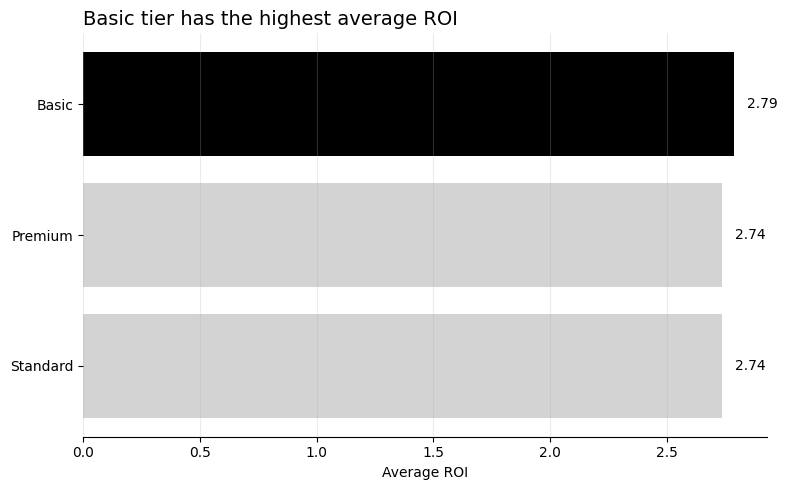

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("marketing_and_product_performance.csv")
df.columns = df.columns.str.strip().str.lower()

# Create ROI by subscription tier
tier_roi = (
    df.groupby("subscription_tier")["roi"]
    .mean()
    .sort_values()
)

# Highlight the best-performing tier
highlight_tier = tier_roi.idxmax()

plt.figure(figsize=(8, 5))
ax = plt.gca()

colors = ["lightgray" if tier != highlight_tier else "black" for tier in tier_roi.index]

ax.barh(tier_roi.index, tier_roi.values, color=colors)

# Direct labels
for i, value in enumerate(tier_roi.values):
    ax.text(value + (tier_roi.max() * 0.02), i, f"{value:.2f}", va="center")

# Declutter
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

ax.set_title(f"{highlight_tier} tier has the highest average ROI", loc="left", fontsize=14)
ax.set_xlabel("Average ROI")
ax.set_ylabel("")

plt.tight_layout()
plt.show()